# ChromSeek Hi-C Enhancement Workflow

Welcome to the **ChromSeek** user-friendly workflow for Hi-C matrix enhancement!
This notebook will guide you through:
1. Selecting your reference genome.
2. Providing a Hi-C matrix (via `10kb` .mcool or .npy).
3. Defining your target region (Chromosome + Start Bin).
4. Running the pre-trained `StrongFusionModel_V4` to dramatically boost your Hi-C resolution.


In [1]:
# ==========================================
# 1. Configuration & Setup
# ==========================================

# 1. Reference Genome (Currently 'hg38' is supported, uses the local cache)
REF_GENOME = "hg38" 

# 2. Input Data Strategy:
# Set to 'mcool' if you are providing an mcool file.
# Set to 'numpy' if you are providing a 224x224 numpy array directly.
DATA_STRATEGY = "mcool" 

# 3. Path to your data
# Example for mcool: "example_data/GSM8541475_GM-1000U_003.mcool"
# Example for numpy: "example_data/sample_hg38_chr1_1000.npy"
DATA_PATH = "example_data/GSM8541475_GM-1000U_003.mcool"

# 4. Region of Interest (10kb resolution)
CHROMOSOME = "chr1"
START_BIN_ID = 1000  # Will fetch bins [START_BIN_ID, START_BIN_ID + 224]

# Model Checkpoint
CKPT_PATH = "hic_enhancement/chromSeek_hic_enhancement.pth"

print(f"✅ Configured to enhance {CHROMOSOME} starting at bin {START_BIN_ID} from {DATA_PATH}")


✅ Configured to enhance chr1 starting at bin 1000 from example_data/GSM8541475_GM-1000U_003.mcool


In [2]:
# ==========================================
# 2. Load Dependencies & Imports
# ==========================================
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

# Tools for Hi-C / DNA
import cooler

# Add our project utils to path
sys.path.append(os.path.abspath("utils"))
from DNA_loader import build_one_hot_table, get_encoded_segment, load_chr
from hic_enhancement.model import StrongFusionModel_V4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔌 Using device: {device}")


🔌 Using device: cuda


In [3]:
# ==========================================
# 3. Load Hi-C Matrix & DNA Sequence
# ==========================================
HIC_RESOLUTION = 10000  # 10kb
NUM_BINS = 224
BIN_LENS = NUM_BINS * HIC_RESOLUTION # 2.24Mb

start_bp = START_BIN_ID * HIC_RESOLUTION
end_bp = start_bp + BIN_LENS

# ---- A. Load Hi-C ----
if DATA_STRATEGY == "mcool":
    print(f"Loading from mcool... (resolution={HIC_RESOLUTION})")
    c = cooler.Cooler(f"{DATA_PATH}::/resolutions/{HIC_RESOLUTION}")
    raw_hic = c.matrix(balance=False).fetch((CHROMOSOME, start_bp, end_bp))
elif DATA_STRATEGY == "numpy":
    print("Loading from numpy array...")
    raw_hic = np.load(DATA_PATH)
    if raw_hic.shape != (NUM_BINS, NUM_BINS):
        raise ValueError(f"Expected numpy shape ({NUM_BINS}, {NUM_BINS}), got {raw_hic.shape}")
else:
    raise ValueError(f"Unknown DATA_STRATEGY: {DATA_STRATEGY}")

# ---- B. Load DNA Sequence ----
genome_cache_dir = f"genome_cache_{REF_GENOME}"
if not os.path.isdir(genome_cache_dir):
    raise FileNotFoundError(f"Genome cache directory {genome_cache_dir} not found!")

print(f"Loading {CHROMOSOME} sequence from local cache...")
chr_arr = load_chr(CHROMOSOME, genome_cache_dir, mmap=True)
one_hot_table = build_one_hot_table()

# Make sure we don't go out of bounds
if end_bp > len(chr_arr):
    raise ValueError(f"End position {end_bp} exceeds chromosome {CHROMOSOME} length {len(chr_arr)}")

seq_data = get_encoded_segment(chr_arr, start_bp, end_bp, one_hot_table)
seq_data = seq_data.astype(np.float32, copy=False)

print(f"✅ Hi-C shape: {raw_hic.shape}, Sum contacts: {np.nansum(raw_hic)}")
print(f"✅ DNA shape: {seq_data.shape}")


Loading from mcool... (resolution=10000)
Loading chr1 sequence from local cache...
✅ Hi-C shape: (224, 224), Sum contacts: 1083
✅ DNA shape: (2240000, 4)


In [4]:
# ==========================================
# 4. Preprocessing Data for Model
# ==========================================
# 1. Process DNA
t_seq = torch.from_numpy(seq_data).float().transpose(0, 1) # [4, 2240000]
t_seq = t_seq.unsqueeze(0).to(device)                      # [1, 4, 2240000]

# 2. Process Hi-C
raw_hic = np.nan_to_num(raw_hic, nan=0.0, posinf=0.0, neginf=0.0)
raw_hic = np.clip(raw_hic, 0, None)

# Model expects log1p scaled input:
t_hic = torch.from_numpy(raw_hic).float()
t_hic = torch.log1p(t_hic)           # Application of log1p

# Max scaling (as used in training)
max_val = t_hic.max()
if max_val > 0:
    t_hic = t_hic / max_val
    
t_hic = t_hic.unsqueeze(0).unsqueeze(0).to(device) # [1, 1, 224, 224]

print("✅ Tensors ready for model:")
print("  DNA:", t_seq.shape)
print("  Hi-C:", t_hic.shape)


✅ Tensors ready for model:
  DNA: torch.Size([1, 4, 2240000])
  Hi-C: torch.Size([1, 1, 224, 224])


In [5]:
# ==========================================
# 5. Model Inference
# ==========================================
print("Loading model architecture and weights...")
model = StrongFusionModel_V4().to(device)

if not os.path.exists(CKPT_PATH):
    raise FileNotFoundError(f"Model checkpoint not found at {CKPT_PATH}!")
    
state_dict = torch.load(CKPT_PATH, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.eval()

print("Running Enhancement Inference...")
with torch.no_grad():
    with torch.amp.autocast('cuda' if torch.cuda.is_available() else 'cpu'):
        _, out_2d = model(t_seq, t_hic)
    
    # Model output is directly the predicted log1p Hi-C map
    pred_hic = out_2d.squeeze().cpu().numpy()
    pred_hic = np.clip(pred_hic, 0, None)
    
print("✅ Inference complete!")


Loading model architecture and weights...
Running Enhancement Inference...
✅ Inference complete!


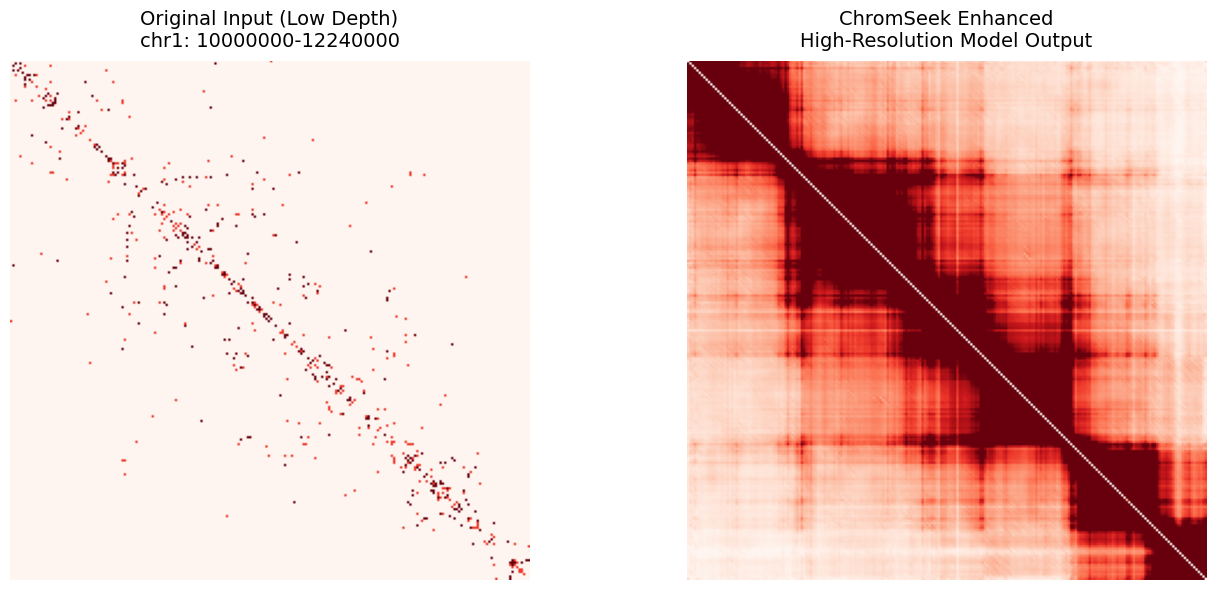

In [6]:
# ==========================================
# 6. Visualization & Comparison
# ==========================================
def plot_matrix(ax, matrix, title, is_already_logged=False):
    # If the raw matrix isn't logged yet, we log it just for scaling/visualization aesthetics
    log_mat = matrix.copy() if is_already_logged else np.log1p(matrix)
    
    # Clip at 80th percentile internally for rich contrast
    p80 = np.percentile(log_mat[log_mat > 0], 80) if np.sum(log_mat > 0) > 0 else 1.0
    if p80 == 0: p80 = 1e-3
    
    im = ax.imshow(log_mat, cmap='Reds', vmin=0, vmax=p80)
    ax.set_title(title, fontsize=14, pad=10)
    ax.axis('off')
    return im

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Original Raw Matrix
# raw_hic is linear read count, so we flag it as not logged.
plot_matrix(axes[0], raw_hic, f"Original Input (Low Depth)\n{CHROMOSOME}: {start_bp}-{end_bp}", is_already_logged=False)

# Right: Model Prediction
# pred_hic is natively in log1p domain
plot_matrix(axes[1], pred_hic, f"ChromSeek Enhanced\nHigh-Resolution Model Output", is_already_logged=True)

plt.tight_layout()
plt.show()

# If you would like to test the pure numpy data workflow, you can set DATA_STRATEGY = 'numpy' and run again!


In [7]:
# ==========================================
# 7. Loading TAD Prediction Model
# ==========================================
import torch.nn.functional as F
from tad_prediction.model import DnaHicTadPredictor

TAD_CKPT_PATH = "tad_prediction/chromSeek_tad_prediction.pth"

print("Initializing TAD predictor model...")
tad_model = DnaHicTadPredictor().to(device)

if not os.path.exists(TAD_CKPT_PATH):
    raise FileNotFoundError(f"TAD Checkpoint missing: {TAD_CKPT_PATH}")

state_dict = torch.load(TAD_CKPT_PATH, map_location=device, weights_only=True)
if list(state_dict.keys())[0].startswith("module."):
    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
tad_model.load_state_dict(state_dict)
tad_model.eval()

print("✅ TAD Predictor Ready!")


Initializing TAD predictor model...
✅ TAD Predictor Ready!


In [8]:
# ==========================================
# 8. Run TAD Prediction
# ==========================================
def cluster_and_nms(pred_prob, threshold=0.5, max_gap=50):
    pred_classes = np.zeros_like(pred_prob, dtype=int)
    valid_idx = np.where(pred_prob > threshold)[0]
    if len(valid_idx) == 0:
        return pred_classes
        
    clusters = []
    current_cluster = [valid_idx[0]]
    for idx in valid_idx[1:]:
        if idx - current_cluster[-1] <= max_gap:
            current_cluster.append(idx)
        else:
            clusters.append(current_cluster)
            current_cluster = [idx]
    clusters.append(current_cluster)
    
    for cluster in clusters:
        best_idx_in_cluster = cluster[np.argmax(pred_prob[cluster])]
        pred_classes[best_idx_in_cluster] = 1
    return pred_classes

def format_tads_from_boundaries(boundaries_1kb):
    b = set(boundaries_1kb)
    if 0 not in b: b.add(0)
    if 2239 not in b: b.add(2239)
    b_sorted = np.sort(list(b))
    tads = []
    for i in range(len(b_sorted) - 1):
        if b_sorted[i+1] - b_sorted[i] >= 10:
            tads.append((b_sorted[i] / 10.0, b_sorted[i+1] / 10.0))
    return tads

print("Running TAD Inference using the SAME pre-processed DNA & Hi-C tensors...")

with torch.no_grad():
    with torch.amp.autocast('cuda' if torch.cuda.is_available() else 'cpu'):
        tad_out = tad_model(t_seq, t_hic)
        
    # The output logit has shape (B, 2, L). Class 1 corresponds to "boundary found"
    pred_prob = F.softmax(tad_out, dim=1)[:, 1, :].squeeze().cpu().numpy()

# Dynamic threshold mapping (95th percentile) for sparse data adaptation
dyn_threshold = np.percentile(pred_prob, 95)
print(f"Dynamic TAD threshold (95th percentile): {dyn_threshold:.4f}")
pred_nms = cluster_and_nms(pred_prob, threshold=dyn_threshold, max_gap=50)
pred_boundaries = np.where(pred_nms == 1)[0]
pred_tads = format_tads_from_boundaries(pred_boundaries)

print(f"✅ Predicted {len(pred_tads)} TADs within this region!")


Running TAD Inference using the SAME pre-processed DNA & Hi-C tensors...
Dynamic TAD threshold (95th percentile): 0.0004
✅ Predicted 10 TADs within this region!


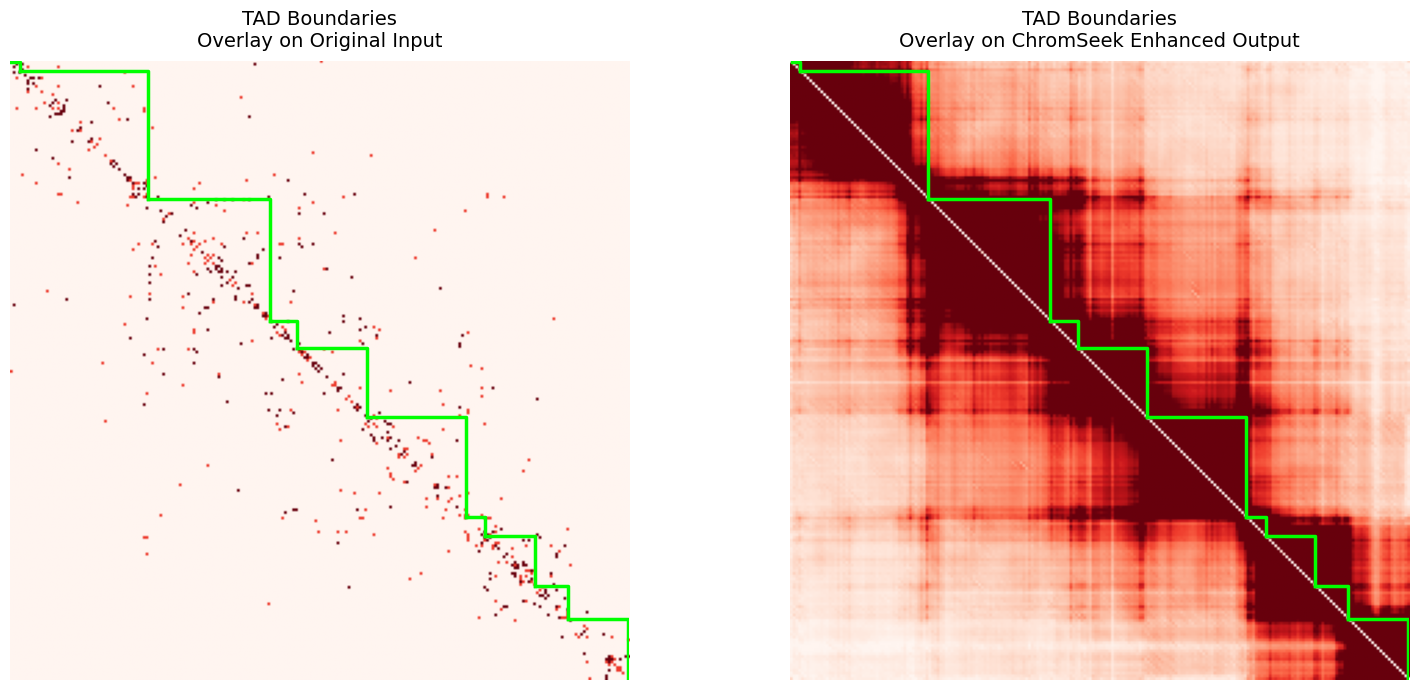

In [9]:
# ==========================================
# 9. Visualize TAD Boundaries on High-Res Hi-C
# ==========================================
import matplotlib.patches as patches

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Helper to plot both the map and the TAD triangles
def plot_tads_on_hic(ax, hic_mat, tads, title, is_already_logged=True):
    log_mat = hic_mat.copy() if is_already_logged else np.log1p(hic_mat)
    p80 = np.percentile(log_mat[log_mat > 0], 80) if np.sum(log_mat > 0) > 0 else 1.0
    if p80 == 0: p80 = 1e-3
    
    ax.imshow(log_mat, cmap='Reds', vmin=0, vmax=p80)
    
    # Overlay TAD boxes
    for (b_start, b_end) in tads:
        width = b_end - b_start
        if width > 0:
            x_coords = [b_start, b_end, b_end]
            y_coords = [b_start, b_start, b_end]
            ax.plot(x_coords, y_coords, color='lime', linewidth=2.5)
            
    ax.set_title(title, fontsize=14, pad=10)
    ax.axis('off')

# Map 1: TADs on Raw Input
plot_tads_on_hic(axes[0], raw_hic, pred_tads, f"TAD Boundaries\nOverlay on Original Input", is_already_logged=False)

# Map 2: TADs on Enhanced Model Output
plot_tads_on_hic(axes[1], pred_hic, pred_tads, f"TAD Boundaries\nOverlay on ChromSeek Enhanced Output", is_already_logged=True)

plt.tight_layout()
plt.show()
